## Model Training

This sections serves to use the prepared and cleaned dataset and use the model to train with the dataset.

### Dataset Loading

In [1]:
## Load Dataset

import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from gensim.models import FastText
from nltk.tokenize import word_tokenize
from torch.utils.data import DataLoader
from dataset_class.job_post_dataset import JobPostingDataset
from model_construction.model import FakeJobDetector
import os, json, pickle
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import itertools

torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

combined_df = pd.read_csv("./data/clean/fake_job_postings_ALL.csv")


numeric_cols = ["telecommuting", "missing_count", "total_text_len", "company_profile_len", "description_len", 
                "requirements_len", "company_profile_word_count", "description_word_count", 
                "requirements_word_count", "salary_provided", "has_company_profile",
                "vague_location", "has_company_logo", "has_questions","benefits_len","benefits_word_count",]
non_binary_cols = [
    "missing_count",          
    "total_text_len", 
    "company_profile_len", 
    "description_len", 
    "requirements_len", 
    "benefits_len", 
    "company_profile_word_count", 
    "description_word_count", 
    "requirements_word_count", 
    "benefits_word_count"
]
numerical_array = combined_df[numeric_cols].to_numpy(dtype=np.float32)  # (N, 16)
labels_array    = combined_df['fraudulent'].to_numpy(dtype=np.float32)  # (N,)

print(numerical_array.shape)
print(labels_array.shape)

print(f"Dataset: {combined_df.shape[0]} rows, {combined_df.shape[1]} cols")
print(f"Class balance: {combined_df['fraudulent'].value_counts().to_dict()}")



(17880, 16)
(17880,)
Dataset: 17880 rows, 18 cols
Class balance: {0: 17014, 1: 866}


### Train - Test - Validation Split

Conducted a 80 - 10 - 10 split for train, test and validation, stratifying with the label column to ensure the same distribution in each dataset.

In [2]:


# Split 80% Train, 20% "Rest" (temp_data)
# Stratify based on 'fraudulent' column to maintain class distribution in both sets
train_data, temp_data = train_test_split(
    combined_df, test_size=0.2, random_state=42, stratify=combined_df['fraudulent']
)

# Split that 20% into half (10% Val, 10% Test)
# Use temp_data['fraudulent'] for stratification
val_data, test_data = train_test_split(
    temp_data, test_size=0.5, random_state=42, stratify=temp_data['fraudulent']
)

# Convert to lists and numpy arrays to store as tensors later

X_train_text = train_data['full_text'].tolist()
X_train_numeric = train_data[numeric_cols].values.astype(np.float32)
y_train = train_data['fraudulent'].values.tolist()

X_val_text = val_data['full_text'].tolist()
X_val_numeric = val_data[numeric_cols].values.astype(np.float32)
y_val = val_data['fraudulent'].values.tolist()

X_test_text = test_data['full_text'].tolist()
X_test_numeric = test_data[numeric_cols].values.astype(np.float32)
y_test = test_data['fraudulent'].values.tolist()

print(f"Train: {len(y_train)}, Val: {len(y_val)}, Test: {len(y_test)}")

Train: 14304, Val: 1788, Test: 1788


### Non-binary value Standardisation

We standardise only the non-binary numeric values 

In [3]:


non_binary_cols = [
    "missing_count",          
    "total_text_len", 
    "company_profile_len", 
    "description_len", 
    "requirements_len", 
    "benefits_len", 
    "company_profile_word_count", 
    "description_word_count", 
    "requirements_word_count", 
    "benefits_word_count"
]

non_binary_indices = [numeric_cols.index(col) for col in non_binary_cols]

scaler = StandardScaler()

# Scale in-place, preserving original column order
X_train_numeric[:, non_binary_indices] = scaler.fit_transform(X_train_numeric[:, non_binary_indices])
X_val_numeric[:,   non_binary_indices] = scaler.transform(X_val_numeric[:,     non_binary_indices])
X_test_numeric[:,  non_binary_indices] = scaler.transform(X_test_numeric[:,    non_binary_indices])

# Verify
print(X_train_numeric.mean(axis=0).round(3))  # non-binary cols ≈ 0.0
print(X_train_numeric.std(axis=0).round(3))   # non-binary cols ≈ 1.0

[ 0.042 -0.     0.    -0.     0.     0.     0.     0.    -0.     0.16
  0.813  0.025  0.793  0.493  0.    -0.   ]
[0.2   1.    1.    1.    1.    1.    1.    1.    1.    0.366 0.39  0.156
 0.405 0.5   1.    1.   ]


### Loading of fine-tuned FastText model

In [4]:


fasttext_model_optimal = FastText.load("./optimal_fasttext.bin")

print(fasttext_model_optimal.wv.similarity('software', 'engineer'))
print(fasttext_model_optimal.wv.similarity('skills', 'experience'))
print(fasttext_model_optimal.wv.most_similar('water', topn=10))

print(f"FastText vocab: {len(fasttext_model_optimal.wv)} words, {fasttext_model_optimal.wv.vector_size}-dim")

0.43897995
0.5301568
[('groundwater', 0.7882607579231262), ('wastewater', 0.7729810476303101), ('watering', 0.7443079352378845), ('stormwater', 0.7438472509384155), ('waters', 0.7296249866485596), ('deepwater', 0.7160226702690125), ('waterfalls', 0.6929528117179871), ('waterloo', 0.6815873980522156), ('underwater', 0.6692019104957581), ('waterbabies', 0.6511003971099854)]
FastText vocab: 26971 words, 100-dim


### Tokenizing and encoding tokens into numerical values

These tokens and numerical representations are cached thereafter so as to save time from tokenizing and encoding all of the datasets.

In [5]:
CACHE_DIR = "./data/cache"
os.makedirs(CACHE_DIR, exist_ok=True)

tok_cache   = os.path.join(CACHE_DIR, "tokenized_splits.pkl")
vocab_cache = os.path.join(CACHE_DIR, "vocab.json")

if os.path.exists(tok_cache) and os.path.exists(vocab_cache):
    #Load cached tokenized data
    print("Loading cached tokenized data...")
    with open(tok_cache, "rb") as f:
        cached = pickle.load(f)
    train_texts_tok = cached["train"]
    val_texts_tok   = cached["val"]
    test_texts_tok  = cached["test"]

    with open(vocab_cache, "r") as f:
        vocab = json.load(f)

    print(f"Vocab size: {len(vocab)} (loaded from cache)")
else:
    #Tokenize and encode from scratch
    print("Tokenizing (first run, will be cached)...")
    train_tk = [word_tokenize(text.lower()) for text in X_train_text]
    val_tk   = [word_tokenize(text.lower()) for text in X_val_text]
    test_tk  = [word_tokenize(text.lower()) for text in X_test_text]

    # Build vocab from FastText (0=<unk>, 1=<pad>, 2+=words)
    vocab = {"<unk>": 0, "<pad>": 1}
    for idx, word in enumerate(fasttext_model_optimal.wv.index_to_key):
        vocab[word] = idx + 2

    def encode(tokens, vocab):
        return [vocab.get(t, 0) for t in tokens]

    train_texts_tok = [encode(s, vocab) for s in train_tk]
    val_texts_tok   = [encode(s, vocab) for s in val_tk]
    test_texts_tok  = [encode(s, vocab) for s in test_tk]

    # Save cache
    with open(tok_cache, "wb") as f:
        pickle.dump({"train": train_texts_tok, "val": val_texts_tok, "test": test_texts_tok}, f)
    with open(vocab_cache, "w") as f:
        json.dump(vocab, f)

    print(f"Vocab size: {len(vocab)} (saved to cache)")

Tokenizing (first run, will be cached)...
Vocab size: 26973 (saved to cache)


### Instantiating Datasets

In [6]:
#Create Datasets and DataLoader
MAX_LEN    = 2048
BATCH_SIZE = 64
torch.manual_seed(42)
torch.cuda.manual_seed(42)

train_dataset = JobPostingDataset(train_texts_tok, X_train_numeric, y_train, max_len=MAX_LEN)
val_dataset   = JobPostingDataset(val_texts_tok,   X_val_numeric,   y_val,   max_len=MAX_LEN)
test_dataset  = JobPostingDataset(test_texts_tok,  X_test_numeric,  y_test,  max_len=MAX_LEN)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_dataloader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_dataloader)}, Val: {len(val_dataloader)}, Test: {len(test_dataloader)}")

Train batches: 224, Val: 28, Test: 28


### Testing Dataloader by sampling a batch

In [7]:
inputs,label = train_dataset[0]
print("input_ids shape:          ", inputs["input_ids"].shape)           # (2048,)
print("attention_mask shape:     ", inputs["attention_mask"].shape)      # (2048,)
print("numerical_features shape: ", inputs["numerical_features"].shape)  # (num_features,)
print("label:                    ", label)


input_ids shape:           torch.Size([2048])
attention_mask shape:      torch.Size([2048])
numerical_features shape:  torch.Size([16])
label:                     tensor(0.)


### Creating the embedding matrix

This is used to copy into the embedding layer


In [8]:

vocab_size = len(vocab)
embed_dim  = fasttext_model_optimal.wv.vector_size

embedding_matrix = np.zeros((vocab_size, embed_dim), dtype=np.float32)
# index 0 (<unk>) stays zero
# index 1 (<pad>) stays zero

for word, idx in vocab.items():
    if word in fasttext_model_optimal.wv:
        embedding_matrix[idx] = fasttext_model_optimal.wv[word]

pretrained_embeddings = torch.tensor(embedding_matrix, dtype=torch.float)
print(f"Embedding matrix: {pretrained_embeddings.shape}")  # torch.Size([vocab_size, 100])

Embedding matrix: torch.Size([26973, 100])


### Model Instantiation

In [9]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FakeJobDetector(
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    num_numerical_features=X_train_numeric.shape[1],
    pretrained_embeddings=pretrained_embeddings,
    gru_hidden_dim=64,
    num_hidden_dim=128,
    device=device,
)

print(model)

FakeJobDetector(
  (embedding): Embedding(26973, 100, padding_idx=1)
  (bigru): BiGRUBlock(
    (gru): GRU(100, 64, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  )
  (attention): MultiHeadAttentionPooling(
    (heads): ModuleList(
      (0-1): 2 x Linear(in_features=128, out_features=1, bias=True)
    )
    (projection): Linear(in_features=256, out_features=128, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (numerical): NumericalBlock(
    (layers): Sequential(
      (0): Linear(in_features=16, out_features=128, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.3, inplace=False)
      (3): Linear(in_features=128, out_features=128, bias=True)
      (4): ReLU()
      (5): Dropout(p=0.3, inplace=False)
    )
  )
  (classifier): Linear(in_features=256, out_features=1, bias=True)
)


### Model Training

Training with a chosen number of epochs and learning rate and a dedicated saving path to store the best weights.

In [10]:
train_losses, val_losses, train_accuracy, val_accuracy = model.fit(
    dataloader     = train_dataloader,
    val_dataloader = val_dataloader,
    num_epochs     = 20,
    learning_rate  = 1e-3,
    save_path      = "best_model.pt",
)





Epoch 1/20 | Train Loss: 0.0450 | Val Loss: 0.0413
  ✅ Best model saved (val_loss=0.0413)
Epoch 2/20 | Train Loss: 0.0391 | Val Loss: 0.0395
  ✅ Best model saved (val_loss=0.0395)
Epoch 3/20 | Train Loss: 0.0342 | Val Loss: 0.0331
  ✅ Best model saved (val_loss=0.0331)
Epoch 4/20 | Train Loss: 0.0263 | Val Loss: 0.0272
  ✅ Best model saved (val_loss=0.0272)
Epoch 5/20 | Train Loss: 0.0207 | Val Loss: 0.0207
  ✅ Best model saved (val_loss=0.0207)
Epoch 6/20 | Train Loss: 0.0167 | Val Loss: 0.0151
  ✅ Best model saved (val_loss=0.0151)
Epoch 7/20 | Train Loss: 0.0170 | Val Loss: 0.0161
  ⚠️ No improvement (best_val_loss=0.0151)
Epoch 8/20 | Train Loss: 0.0157 | Val Loss: 0.0152
  ⚠️ No improvement (best_val_loss=0.0151)
Epoch 9/20 | Train Loss: 0.0143 | Val Loss: 0.0172
  ⚠️ No improvement (best_val_loss=0.0151)
Epoch 10/20 | Train Loss: 0.0144 | Val Loss: 0.0130
  ✅ Best model saved (val_loss=0.0130)
Epoch 11/20 | Train Loss: 0.0149 | Val Loss: 0.0268
  ⚠️ No improvement (best_val_loss=

### Hyperparameter Threshold Tuning
This is done with the test dataset.

In [11]:
for threshold in [0.2, 0.3, 0.4, 0.5, 0.55, 0.6, 0.7, 0.8]:
    print(f"\n--- Threshold: {threshold} ---")
    model.evaluate(test_dataloader, threshold=threshold)


--- Threshold: 0.2 ---
              precision    recall  f1-score   support

        Real       1.00      0.91      0.95      1702
        Fake       0.36      0.98      0.52        86

    accuracy                           0.91      1788
   macro avg       0.68      0.94      0.74      1788
weighted avg       0.97      0.91      0.93      1788


--- Threshold: 0.3 ---
              precision    recall  f1-score   support

        Real       1.00      0.98      0.99      1702
        Fake       0.66      0.94      0.78        86

    accuracy                           0.97      1788
   macro avg       0.83      0.96      0.88      1788
weighted avg       0.98      0.97      0.98      1788


--- Threshold: 0.4 ---
              precision    recall  f1-score   support

        Real       1.00      0.99      0.99      1702
        Fake       0.81      0.91      0.86        86

    accuracy                           0.99      1788
   macro avg       0.90      0.95      0.92      1788
we

### Model Branch Evaluation

Compare the performance of both the NLP and numeric branch to observe the contributions made to the final scores in the classification matrix

In [12]:
model.evaluate_branches(test_dataloader, threshold=0.5)


Full model
              precision    recall  f1-score   support

        Real       0.99      0.99      0.99      1702
        Fake       0.86      0.88      0.87        86

    accuracy                           0.99      1788
   macro avg       0.93      0.94      0.93      1788
weighted avg       0.99      0.99      0.99      1788


NLP only
              precision    recall  f1-score   support

        Real       1.00      0.99      0.99      1702
        Fake       0.86      0.91      0.88        86

    accuracy                           0.99      1788
   macro avg       0.93      0.95      0.94      1788
weighted avg       0.99      0.99      0.99      1788


Numerical only
              precision    recall  f1-score   support

        Real       0.97      0.93      0.95      1702
        Fake       0.24      0.48      0.32        86

    accuracy                           0.90      1788
   macro avg       0.61      0.70      0.64      1788
weighted avg       0.94      0.90   

c:\Users\Chadrick\Documents\python_trial\fake-job-posting_DL_Project_rerun\.venv310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Chadrick\Documents\python_trial\fake-job-posting_DL_Project_rerun\.venv310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Chadrick\Documents\python_trial\fake-job-posting_DL_Project_rerun\.venv310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no pre

### Loss and Accuracy Visualisations

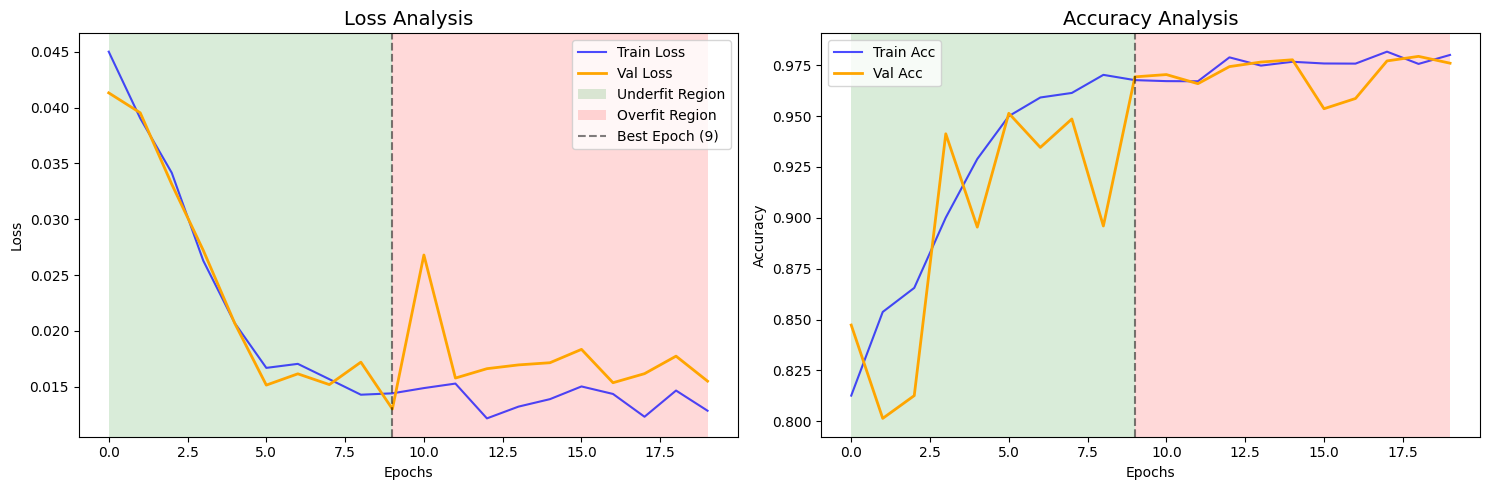

In [13]:


# Find the index of the lowest validation loss
best_epoch = val_losses.index(min(val_losses))
total_epochs = len(val_losses)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# loss plot
ax1.plot(train_losses, label='Train Loss', color='blue', alpha=0.7)
ax1.plot(val_losses, label='Val Loss', color='orange', linewidth=2)

# Dynamic spans based on best_epoch
ax1.axvspan(0, best_epoch, facecolor='green', alpha=0.15, label="Underfit Region")
ax1.axvspan(best_epoch, total_epochs - 1, facecolor='red', alpha=0.15, label="Overfit Region")

# Add a vertical line at the "sweet spot"
ax1.axvline(best_epoch, color='black', linestyle='--', alpha=0.5, label=f'Best Epoch ({best_epoch})')

ax1.set_title('Loss Analysis', fontsize=14)
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

# Accuracy plot
ax2.plot(train_accuracy, label='Train Acc', color='blue', alpha=0.7)
ax2.plot(val_accuracy, label='Val Acc', color='orange', linewidth=2)

# show the zones on the accuracy plot as well for consistency
ax2.axvspan(0, best_epoch, facecolor='green', alpha=0.15)
ax2.axvspan(best_epoch, total_epochs - 1, facecolor='red', alpha=0.15)
ax2.axvline(best_epoch, color='black', linestyle='--', alpha=0.5)

ax2.set_title('Accuracy Analysis', fontsize=14)
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()


### Confusion Matrix Report Visualisation

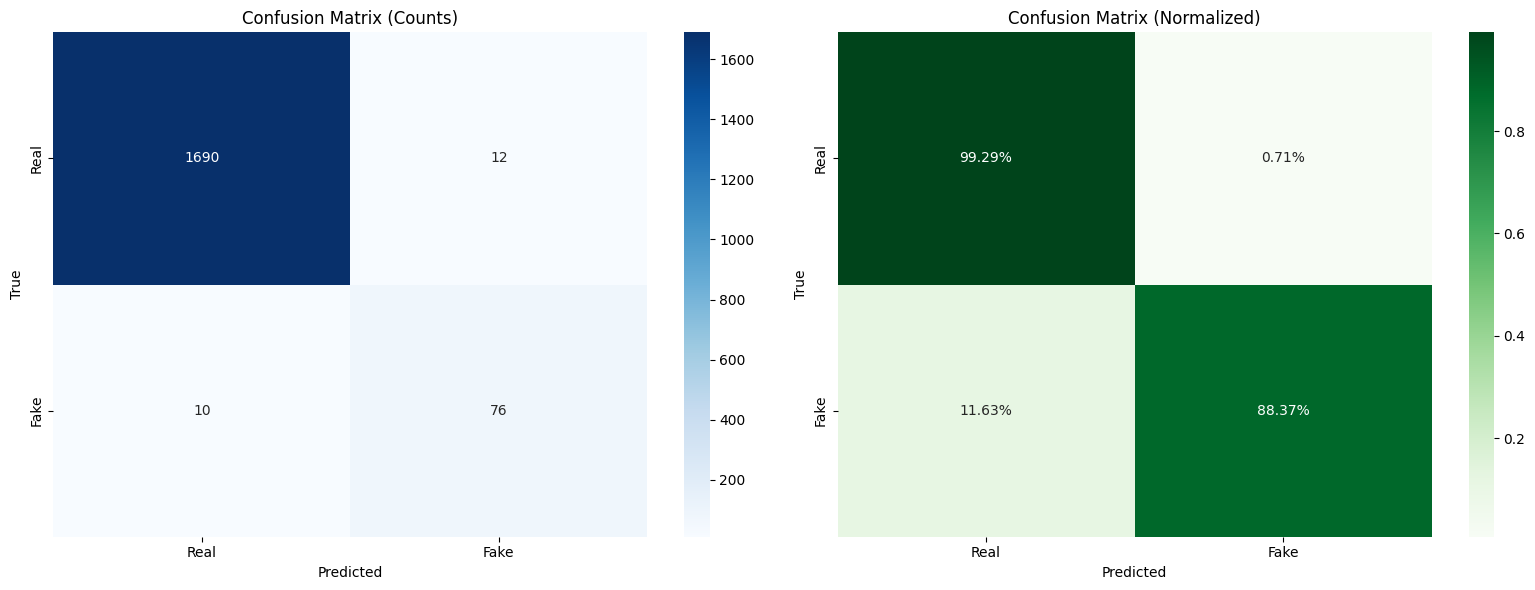

In [14]:


def plot_confusion_matrix(model, iterator, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, targets in iterator:
            # Move all inputs to device
            input_ids = inputs['input_ids'].to(device)
            attention_mask = inputs['attention_mask'].to(device)
            numerical_features = inputs['numerical_features'].to(device)
            targets = targets.to(device).float()

            outputs = model(input_ids, attention_mask, numerical_features).squeeze()
            preds = torch.round(torch.sigmoid(outputs)) 
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(targets.cpu().numpy())

    # Compute Matrices
    cm = confusion_matrix(all_labels, all_preds)
    # Normalize by the number of true labels (rows)
    cm_norm = confusion_matrix(all_labels, all_preds, normalize='true')

    # Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    labels = ['Real', 'Fake']

    # --- Raw Counts ---
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
                xticklabels=labels, yticklabels=labels)
    ax1.set_title('Confusion Matrix (Counts)')
    ax1.set_xlabel('Predicted')
    ax1.set_ylabel('True')

    # --- Normalized ---
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens', ax=ax2,
                xticklabels=labels, yticklabels=labels)
    ax2.set_title('Confusion Matrix (Normalized)')
    ax2.set_xlabel('Predicted')
    ax2.set_ylabel('True')

    plt.tight_layout()
    plt.show()
        



plot_confusion_matrix(model, test_dataloader, device)

### Hyperparameter GRU/Hidden layer dimension tuning

In [16]:


# Define search space
gru_dims     = [32, 64]
num_dims     = [32, 64, 128]
combinations = list(itertools.product(gru_dims, num_dims))  # 6 combinations

results = []

for gru_hidden_dim, num_hidden_dim in combinations:
    print(f"\n{'='*50}")
    print(f"Training: gru_hidden_dim={gru_hidden_dim}, num_hidden_dim={num_hidden_dim}")
    print(f"{'='*50}")

    # Fresh model for each combination
    model = FakeJobDetector(
        vocab_size             = vocab_size,
        embed_dim              = embed_dim,
        gru_hidden_dim         = gru_hidden_dim,
        num_numerical_features = X_train_numeric.shape[1],
        num_hidden_dim         = num_hidden_dim,
        pretrained_embeddings  = pretrained_embeddings,
        device                 = device,
    ).to(device)

    save_path = f"model_gru{gru_hidden_dim}_num{num_hidden_dim}.pt"

    train_losses, val_losses, _, _ = model.fit(
        dataloader     = train_dataloader,
        val_dataloader = val_dataloader,
        num_epochs     = 20,
        learning_rate  = 1e-3,
        save_path      = save_path,
    )

    best_val_loss = min(val_losses)

    #   Evaluate on test set with a fixed threshold (e.g., 0.5) to compare across models
    print(f"\n--- Threshold: 0.5 ---")
    model.evaluate(test_dataloader, threshold=0.5)

    results.append({
        "gru_hidden_dim" : gru_hidden_dim,
        "num_hidden_dim" : num_hidden_dim,
        "best_val_loss"  : best_val_loss,
        "save_path"      : save_path,
    })

    print(f"Best val loss: {best_val_loss:.4f}")


# rank results by best_val_loss
results.sort(key=lambda x: x["best_val_loss"])

print("\n===== HYPERPARAMETER TUNING RESULTS =====")
for rank, r in enumerate(results, 1):
    print(f"#{rank} | gru={r['gru_hidden_dim']}, num={r['num_hidden_dim']} "
          f"| val_loss={r['best_val_loss']:.4f} | saved: {r['save_path']}")

# Best combo
best = results[0]
print(f"\nBest config → gru_hidden_dim={best['gru_hidden_dim']}, "
      f"num_hidden_dim={best['num_hidden_dim']} (val_loss={best['best_val_loss']:.4f})")


Training: gru_hidden_dim=32, num_hidden_dim=32
Epoch 1/20 | Train Loss: 0.0490 | Val Loss: 0.0412
  ✅ Best model saved (val_loss=0.0412)
Epoch 2/20 | Train Loss: 0.0376 | Val Loss: 0.0341
  ✅ Best model saved (val_loss=0.0341)
Epoch 3/20 | Train Loss: 0.0311 | Val Loss: 0.0299
  ✅ Best model saved (val_loss=0.0299)
Epoch 4/20 | Train Loss: 0.0252 | Val Loss: 0.0306
  ⚠️ No improvement (best_val_loss=0.0299)
Epoch 5/20 | Train Loss: 0.0222 | Val Loss: 0.0164
  ✅ Best model saved (val_loss=0.0164)
Epoch 6/20 | Train Loss: 0.0205 | Val Loss: 0.0174
  ⚠️ No improvement (best_val_loss=0.0164)
Epoch 7/20 | Train Loss: 0.0187 | Val Loss: 0.0146
  ✅ Best model saved (val_loss=0.0146)
Epoch 8/20 | Train Loss: 0.0164 | Val Loss: 0.0178
  ⚠️ No improvement (best_val_loss=0.0146)
Epoch 9/20 | Train Loss: 0.0168 | Val Loss: 0.0255
  ⚠️ No improvement (best_val_loss=0.0146)
Epoch 10/20 | Train Loss: 0.0144 | Val Loss: 0.0169
  ⚠️ No improvement (best_val_loss=0.0146)
Epoch 11/20 | Train Loss: 0.014